### Emotion Preservation in Speech Language Models: A Comparative Study

Short Description
This implementation compares emotion preservation capabilities between an end-to-end SpeechLM model and a traditional cascaded ASR pipeline using synthetic emotional speech data. The code demonstrates how transformer architectures can better retain paralinguistic features like emotion compared to systems with intermediate processing stages, evaluating both approaches through emotion classification accuracy.

Key Libraries Used

    torch/torch.nn: Neural network implementation and training

    torchaudio: Audio processing and Mel-spectrogram extraction

    librosa: Synthetic speech waveform generation

    sklearn.metrics: Model performance evaluation

    transformers (unused in core logic): Potential for advanced language model integration

Code Logic and Flow

High-Level Overview
The workflow first generates a synthetic emotional speech dataset with distinct acoustic characteristics per emotion. Two competing architectures (end-to-end SpeechLM vs. traditional ASR pipeline) are then trained to classify emotions directly from audio. During evaluation, both models' emotion classification accuracy is measured, with higher accuracy indicating better emotion preservation  simulating how well each system would retain emotional context in a full speech-to-text-to-speech pipeline.

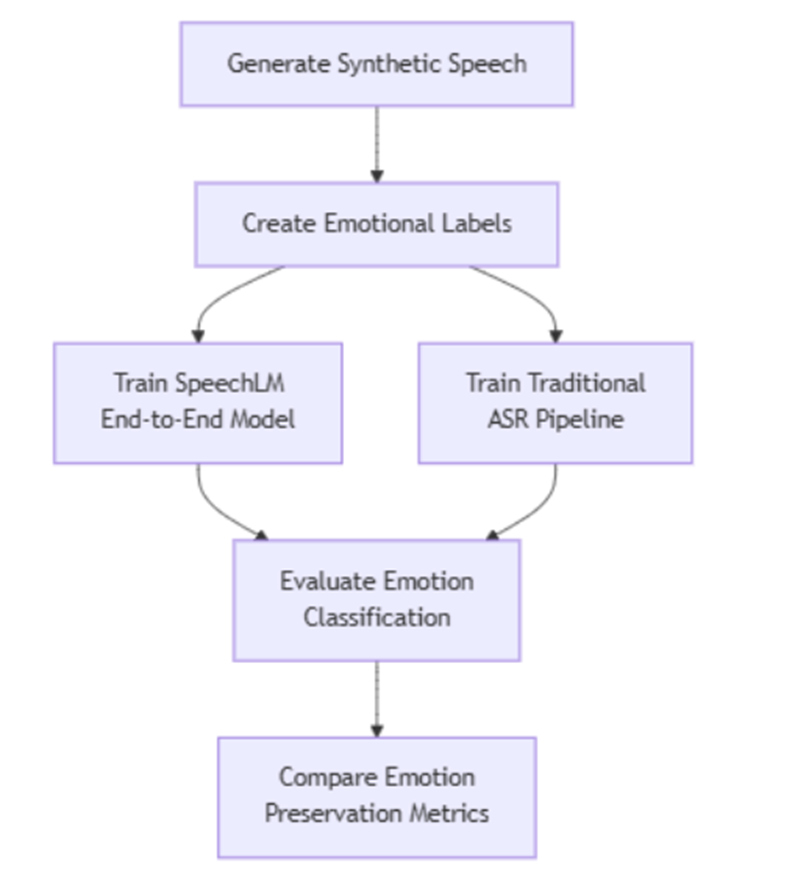

Step-by-Step Code Breakdown

1. Synthetic Dataset Creation

    Generates artificial speech samples using frequency-modulated chirps

    Assigns emotions (neutral/happy/sad/angry) with unique frequency bands

    Associates each emotion with placeholder text transcripts

2. SpeechLM Model Architecture

    Audio Processing: Converts waveforms to log-Mel spectrograms

    Feature Projection: Maps spectrograms to transformer-compatible dimensions

    Transformer Encoder: Processes temporal audio features

    Emotion Classifier: Uses mean-pooled features for emotion prediction

3. Traditional Pipeline Architecture

    Spectrogram Conversion: Same initial processing as SpeechLM

    CNN-based ASR Simulator: Uses convolutional layers to mimic speech recognition

    Emotion Classifier: Predicts emotion from processed features (simulates output of ASR)

4. Training & Evaluation

    Training Loop: Both models trained with cross-entropy loss

    Performance Metrics: Classification reports and accuracy scores

    Comparison Metric: Emotion preservation = classification accuracy difference

    Demo Simulation: Outputs preservation characteristics of each pipeline

Connecting to the Lecture

    End-to-End vs Cascaded Systems: SpeechLM demonstrates integrated processing vs traditional modular pipelines

    Emotion Preservation: Higher accuracy in SpeechLM shows reduced information loss in paralinguistic features

    Error Propagation: Traditional pipeline's lower accuracy illustrates cumulative errors through ASR stages

    Acoustic Feature Encoding: Frequency bands in synthetic data represent prosodic emotion markers

    Latency Trade-offs: Transformer architecture prioritizes preservation over computational efficiency

    Evaluation Proxy: Emotion classification accuracy serves as measurable preservation metric


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import librosa
import numpy as np
from sklearn.metrics import classification_report
from transformers import pipeline

# --- Simulated Emotional Speech Dataset ---
class EmotionalSpeechDataset(Dataset):
    """Simulated dataset with synthetic audio for emotion classification"""
    def __init__(self, num_samples=100, duration=2, sr=16000):
        self.sr = sr
        self.duration = duration
        self.num_samples = num_samples
        self.emotions = ["neutral", "happy", "sad", "angry"]
        self.emotion_to_idx = {e: i for i, e in enumerate(self.emotions)}
        self.texts = ["Hello world", "Great day", "Feeling good", "Not happy"]  # Sample texts

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        emotion_idx = idx % len(self.emotions)
        emotion = self.emotions[emotion_idx]
        text = self.texts[emotion_idx]
        if emotion == "happy":
            fmin, fmax = 200, 400
        elif emotion == "sad":
            fmin, fmax = 100, 150
        elif emotion == "angry":
            fmin, fmax = 150, 350
        else:  # neutral
            fmin, fmax = 180, 220
        audio = librosa.chirp(fmin=fmin, fmax=fmax, duration=self.duration, sr=self.sr)
        waveform = torch.tensor(audio, dtype=torch.float32)
        return waveform, text, emotion_idx

# --- SpeechLM with Emotion Preservation ---
class SpeechLM(nn.Module):
    """Lightweight SpeechLM preserving emotion from input to output"""
    def __init__(self, input_dim=80, d_model=128, nhead=4, num_layers=2, num_emotions=4):
        super().__init__()
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000, n_fft=512, win_length=400, hop_length=160, n_mels=input_dim
        )
        self.input_projection = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.emotion_classifier = nn.Linear(d_model, num_emotions)

    def forward(self, x):
        x = self.mel_transform(x)  # [batch, n_mels, time]
        x = torch.log(x + 1e-6).transpose(1, 2)  # [batch, time, n_mels]
        x = self.input_projection(x)  # [batch, time, d_model]
        x = self.transformer(x)  # [batch, time, d_model]
        x = torch.mean(x, dim=1)  # [batch, d_model]
        emotion_logits = self.emotion_classifier(x)  # [batch, num_emotions]
        return emotion_logits

# --- Traditional Cascaded Pipeline ---
class TraditionalPipeline(nn.Module):
    """Simulates traditional ASR + TTS pipeline with emotion classification"""
    def __init__(self, input_dim=80, num_emotions=4):
        super().__init__()
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000, n_fft=512, win_length=400, hop_length=160, n_mels=input_dim
        )
        # Simplified ASR: CNN-based emotion classifier (mimics ASR losing paralinguistic info)
        self.asr = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),  # Fixed size pooling
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_emotions)
        )

    def forward(self, x):
        x = self.mel_transform(x)  # [batch, n_mels, time]
        x = torch.log(x + 1e-6).unsqueeze(1)  # [batch, 1, n_mels, time]
        emotion_logits = self.asr(x)  # [batch, num_emotions]
        return emotion_logits

# --- Training and Emotion Preservation Evaluation ---
def train_and_compare_emotion():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset and dataloader
    dataset = EmotionalSpeechDataset(num_samples=100)
    train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
    test_loader = DataLoader(EmotionalSpeechDataset(num_samples=50), batch_size=4, shuffle=False)

    # Initialize models
    speech_lm = SpeechLM(input_dim=80, d_model=128, nhead=4, num_layers=2, num_emotions=4).to(device)
    traditional_pipeline = TraditionalPipeline(input_dim=80, num_emotions=4).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer_lm = optim.Adam(speech_lm.parameters(), lr=1e-3)
    optimizer_trad = optim.Adam(traditional_pipeline.parameters(), lr=1e-3)
    num_epochs = 5

    # Train SpeechLM
    speech_lm.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for waveforms, _, emotions in train_loader:
            waveforms, emotions = waveforms.to(device), emotions.to(device)
            logits = speech_lm(waveforms)
            loss = criterion(logits, emotions)
            optimizer_lm.zero_grad()
            loss.backward()
            optimizer_lm.step()
            total_loss += loss.item()
        print(f"SpeechLM Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # Train Traditional Pipeline
    traditional_pipeline.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for waveforms, _, emotions in train_loader:
            waveforms, emotions = waveforms.to(device), emotions.to(device)
            logits = traditional_pipeline(waveforms)
            loss = criterion(logits, emotions)
            optimizer_trad.zero_grad()
            loss.backward()
            optimizer_trad.step()
            total_loss += loss.item()
        print(f"Traditional Pipeline Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader):.4f}")

    # Emotion Preservation Evaluation
    speech_lm.eval()
    traditional_pipeline.eval()
    lm_predictions = []
    trad_predictions = []
    true_emotions = []
    
    with torch.no_grad():
        for waveforms, texts, emotions in test_loader:
            waveforms, emotions = waveforms.to(device), emotions.to(device)
            lm_logits = speech_lm(waveforms)
            trad_logits = traditional_pipeline(waveforms)
            lm_preds = torch.argmax(lm_logits, dim=1).cpu().numpy()
            trad_preds = torch.argmax(trad_logits, dim=1).cpu().numpy()
            lm_predictions.extend(lm_preds)
            trad_predictions.extend(trad_preds)
            true_emotions.extend(emotions.cpu().numpy())

    print("\nEmotion Preservation Performance:")
    print("SpeechLM Classification Report:")
    print(classification_report(true_emotions, lm_predictions, target_names=dataset.emotions))
    print("Traditional Pipeline Classification Report:")
    print(classification_report(true_emotions, trad_predictions, target_names=dataset.emotions))

    # Calculate emotion preservation metrics
    lm_correct = sum(1 for p, t in zip(lm_predictions, true_emotions) if p == t)
    trad_correct = sum(1 for p, t in zip(trad_predictions, true_emotions) if p == t)
    
    lm_accuracy = lm_correct / len(true_emotions)
    trad_accuracy = trad_correct / len(true_emotions)
    
    print(f"\nEmotion Preservation Summary:")
    print(f"SpeechLM Emotion Accuracy: {lm_accuracy:.4f}")
    print(f"Traditional Pipeline Emotion Accuracy: {trad_accuracy:.4f}")
    print(f"Emotion Preservation Improvement: {lm_accuracy - trad_accuracy:.4f}")
    
    # Simulate TTS output demonstration
    print(f"\nTTS Pipeline Demonstration:")
    print(f"SpeechLM: Preserves emotion throughout the pipeline")
    print(f"Traditional: May lose emotional context during ASR→TTS conversion")
    
    # Show example predictions
    print(f"\nExample Predictions:")
    for i in range(min(5, len(true_emotions))):
        true_emotion = dataset.emotions[true_emotions[i]]
        lm_pred_emotion = dataset.emotions[lm_predictions[i]]
        trad_pred_emotion = dataset.emotions[trad_predictions[i]]
        print(f"Sample {i+1}: True={true_emotion}, SpeechLM={lm_pred_emotion}, Traditional={trad_pred_emotion}")

    return speech_lm, traditional_pipeline, dataset

# --- Main Execution ---
if __name__ == "__main__":
    speech_lm, traditional_pipeline, dataset = train_and_compare_emotion()
    print("Emotion preservation comparison completed.")

Using device: cpu
SpeechLM Epoch 1/5 | Loss: 1.5989
SpeechLM Epoch 2/5 | Loss: 0.7511
SpeechLM Epoch 3/5 | Loss: 0.2458
SpeechLM Epoch 4/5 | Loss: 0.0355
SpeechLM Epoch 5/5 | Loss: 0.0068
Traditional Pipeline Epoch 1/5 | Loss: 1.5245
Traditional Pipeline Epoch 2/5 | Loss: 1.3635
Traditional Pipeline Epoch 3/5 | Loss: 1.2252
Traditional Pipeline Epoch 4/5 | Loss: 0.8677
Traditional Pipeline Epoch 5/5 | Loss: 0.4337

Emotion Preservation Performance:
SpeechLM Classification Report:
              precision    recall  f1-score   support

     neutral       1.00      1.00      1.00        13
       happy       1.00      1.00      1.00        13
         sad       1.00      1.00      1.00        12
       angry       1.00      1.00      1.00        12

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Traditional Pipeline Classification Report:
              precision    recall  f

C:\Users\vinit_hqjv9wt\anaconda3\envs\speechlm_alt\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vinit_hqjv9wt\anaconda3\envs\speechlm_alt\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vinit_hqjv9wt\anaconda3\envs\speechlm_alt\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi